In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:

!pip install -q torch torchvision
!pip install -q transformers accelerate datasets
!pip install -q peft bitsandbytes
!pip install -q ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 17.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 27.3 MB/s eta 0:00:00


# dataset split

In [ ]:
# 1. Install necessary libraries (Run this in your first Colab cell)
!pip install -q transformers datasets torch Pillow

# 2. Main Architecture Script
from datasets import load_dataset
from transformers import AutoImageProcessor, AutoModel
import torch

# --- Step 1: Load the Chest X-Ray Dataset ---
print("Loading Indiana University Chest X-Ray Dataset...")
full_dataset = load_dataset("Shrey-1329/cxiu_hf_dataset", split="train")

# Step 1: Split off 20% for the combined Validation/Test pool (Leaving 80% for Train)
train_test_split = full_dataset.train_test_split(test_size=0.2, seed=42)
train_split = train_test_split['train']
test_val_pool = train_test_split['test']

# Step 2: Split the 20% pool strictly in half to create 10% Validation and 10% Test
val_test_split = test_val_pool.train_test_split(test_size=0.5, seed=42)
val_split = val_test_split['train']
test_split = val_test_split['test']

print(f"Training Pool:   {len(train_split)} images")
print(f"Validation Pool: {len(val_split)} images")
print(f"Holdout Test Pool: {len(test_split)} images\n")

Loading Indiana University Chest X-Ray Dataset...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/1.87k [00:00<?, ?B/s]

data/train-00000-of-00003-34bea7eff0b2e4(…):   0%|          | 0.00/369M [00:00<?, ?B/s]

data/train-00001-of-00003-e264f8a8545640(…):   0%|          | 0.00/369M [00:00<?, ?B/s]

data/train-00002-of-00003-b727c3f3dd3884(…):   0%|          | 0.00/370M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/6060 [00:00<?, ? examples/s]

Training Pool:   4848 images
Validation Pool: 606 images
Holdout Test Pool: 606 images



# model pipeline

In [ ]:
import torch
import torch.nn as nn
import gc
import os
from transformers import AutoImageProcessor, AutoModel, AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

# ==========================================
# 1. ENVIRONMENT & VRAM MANAGEMENT
# ==========================================
gc.collect()
torch.cuda.empty_cache()
os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"System initialized. Target compute device: {device}")

# ==========================================
# 2. LOAD VISION ENCODER (RAD-DINO)
# ==========================================
print("Loading Vision Components (RadDINO)...")
vision_processor = AutoImageProcessor.from_pretrained("microsoft/rad-dino")
vision_encoder = AutoModel.from_pretrained("microsoft/rad-dino").to(device)

# Freeze the vision encoder to save memory and preserve pre-trained medical features
vision_encoder.eval()
for param in vision_encoder.parameters():
    param.requires_grad = False

# ==========================================
# 3. LOAD LANGUAGE DECODER (QWEN + LoRA)
# ==========================================
print("Loading Language Components (Qwen-3B Base)...")
llm_id = "Qwen/Qwen2.5-3B-Instruct"

# MATCHED: Reverted to float16 to match T4 training optimizations
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16
)

tokenizer = AutoTokenizer.from_pretrained(llm_id)
tokenizer.pad_token = tokenizer.eos_token

llm = AutoModelForCausalLM.from_pretrained(
    llm_id,
    quantization_config=bnb_config,
    device_map={"": 0},
    low_cpu_mem_usage=True,
    attn_implementation="eager"
)

# Gradient Checkpointing
llm.config.use_cache = False
llm = prepare_model_for_kbit_training(llm)


lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)

efficient_llm = get_peft_model(llm, lora_config)

# Enable gradient checkpointing to save VRAM during training
efficient_llm.gradient_checkpointing_enable()
efficient_llm.enable_input_require_grads()

# ==========================================
# 4. Q-FORMER PROJECTOR
# ==========================================

class QFormerProjector(nn.Module):
    def __init__(self, num_queries=64, vision_dim=768, llm_dim=3584):
        super().__init__()
        self.query_tokens = nn.Parameter(torch.randn(1, num_queries, vision_dim))
        self.cross_attn = nn.MultiheadAttention(embed_dim=vision_dim, num_heads=8, batch_first=True)
        self.norm1 = nn.LayerNorm(vision_dim)
        self.ffn = nn.Sequential(
            nn.Linear(vision_dim, vision_dim * 4),
            nn.GELU(),
            nn.Linear(vision_dim * 4, vision_dim)
        )
        self.norm2 = nn.LayerNorm(vision_dim)
        self.proj = nn.Linear(vision_dim, llm_dim)
        self.llm_norm = nn.LayerNorm(llm_dim)

    def forward(self, patch_embeddings):
        # Exclude the CLS token to focus purely on spatial patches
        spatial_patches = patch_embeddings[:, 1:, :]
        batch_size = spatial_patches.shape[0]
        queries = self.query_tokens.expand(batch_size, -1, -1)

        attn_output, _ = self.cross_attn(query=queries, key=spatial_patches, value=spatial_patches)

        x = self.norm1(queries + attn_output)
        x = self.norm2(x + self.ffn(x))
        return self.llm_norm(self.proj(x))

print("Initializing Q-Former Projector...")
projector = QFormerProjector(num_queries=64, vision_dim=768, llm_dim=efficient_llm.config.hidden_size).to(device)

System initialized. Target compute device: cuda
Loading Vision Components (RadDINO)...


preprocessor_config.json:   0%|          | 0.00/756 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/879 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

...

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Initializing Q-Former Projector...


# training

# first 3 epochs

Loading Architecture for T4 GPU...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
The image processor of type `BitImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Preparing 3-Way Dataset Splits...
Initiating Training Loop...

--- Starting Epoch 1/3 ---
Step 0000/2424 | Loss: 3.8974 | LR: 0.00e+00 | Time/Step: 2.99s


/tmp/ipykernel_4420/3005463022.py:220: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


Step 0050/2424 | Loss: 4.4338 | LR: 2.22e-05 | Time/Step: 0.64s
Step 0100/2424 | Loss: 4.2694 | LR: 4.63e-05 | Time/Step: 0.97s
Step 0150/2424 | Loss: 2.8834 | LR: 6.85e-05 | Time/Step: 0.68s
Step 0200/2424 | Loss: 3.4809 | LR: 9.26e-05 | Time/Step: 0.65s
Step 0250/2424 | Loss: 1.5429 | LR: 1.00e-04 | Time/Step: 0.67s
Step 0300/2424 | Loss: 2.9091 | LR: 1.00e-04 | Time/Step: 0.67s
Step 0350/2424 | Loss: 2.7993 | LR: 9.99e-05 | Time/Step: 0.66s
Step 0400/2424 | Loss: 2.2929 | LR: 9.98e-05 | Time/Step: 0.67s
Step 0450/2424 | Loss: 1.2554 | LR: 9.97e-05 | Time/Step: 0.66s
Step 0500/2424 | Loss: 2.0984 | LR: 9.96e-05 | Time/Step: 0.67s
Step 0550/2424 | Loss: 1.5469 | LR: 9.95e-05 | Time/Step: 0.67s
Step 0600/2424 | Loss: 1.1176 | LR: 9.93e-05 | Time/Step: 0.66s
Step 0650/2424 | Loss: 2.7979 | LR: 9.91e-05 | Time/Step: 0.66s
Step 0700/2424 | Loss: 1.6589 | LR: 9.88e-05 | Time/Step: 0.66s
Step 0750/2424 | Loss: 0.8618 | LR: 9.86e-05 | Time/Step: 0.66s
Step 0800/2424 | Loss: 2.1209 | LR: 9.83

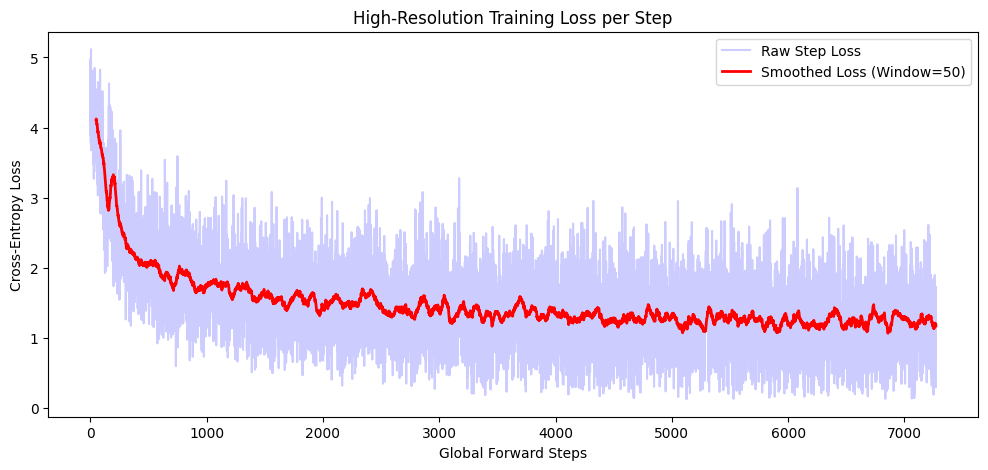


--- ✅ Full Training & Evaluation Run Complete ---


In [ ]:
import os
import random
import time
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import torch
import torch.nn as nn
import torch.backends.cudnn as cudnn
from torch.utils.data import Dataset, DataLoader
from functools import partial
from datasets import load_dataset
from torchvision import transforms
from transformers import AutoImageProcessor, AutoModel, AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig, get_cosine_schedule_with_warmup
from peft import PeftModel, LoraConfig, get_peft_model

# Optimize CuDNN for static input sizes
cudnn.benchmark = True
device = "cuda" if torch.cuda.is_available() else "cpu"

# ==========================================
# 1. LOAD MODELS & ARCHITECTURE
# ==========================================
print("Loading Architecture for T4 GPU...")
vision_processor = AutoImageProcessor.from_pretrained("microsoft/rad-dino")
vision_encoder = AutoModel.from_pretrained("microsoft/rad-dino").to(device)
vision_encoder.eval()

llm_id = "Qwen/Qwen2.5-3B-Instruct"
tokenizer = AutoTokenizer.from_pretrained(llm_id)
tokenizer.pad_token = tokenizer.eos_token

# T4 OPTIMIZATION: Switched to float16 to utilize T4 native Tensor Cores
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16
)
base_llm = AutoModelForCausalLM.from_pretrained(llm_id, quantization_config=bnb_config, device_map={"": 0})

lora_config = LoraConfig(
    r=16, lora_alpha=32, target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
    lora_dropout=0.05, bias="none", task_type="CAUSAL_LM"
)
efficient_llm = get_peft_model(base_llm, lora_config)

class QFormerProjector(nn.Module):
    def __init__(self, num_queries=64, vision_dim=768, llm_dim=3584):
        super().__init__()
        self.query_tokens = nn.Parameter(torch.randn(1, num_queries, vision_dim))
        self.cross_attn = nn.MultiheadAttention(embed_dim=vision_dim, num_heads=8, batch_first=True)
        self.norm1 = nn.LayerNorm(vision_dim)
        self.ffn = nn.Sequential(nn.Linear(vision_dim, vision_dim * 4), nn.GELU(), nn.Linear(vision_dim * 4, vision_dim))
        self.norm2 = nn.LayerNorm(vision_dim)
        self.proj = nn.Linear(vision_dim, llm_dim)
        self.llm_norm = nn.LayerNorm(llm_dim)

    def forward(self, patch_embeddings):
        spatial_patches = patch_embeddings[:, 1:, :]
        batch_size = spatial_patches.shape[0]
        queries = self.query_tokens.expand(batch_size, -1, -1)
        attn_output, _ = self.cross_attn(query=queries, key=spatial_patches, value=spatial_patches)
        x = self.norm1(queries + attn_output)
        x = self.norm2(x + self.ffn(x))
        return self.llm_norm(self.proj(x))

# THE FIX: Initialize normally on the device, Autocast will handle the 16-bit math
projector = QFormerProjector(num_queries=64, vision_dim=768, llm_dim=efficient_llm.config.hidden_size).to(device)

# ==========================================
# 2. DATA LOADER & PIPELINE (SMART BATCHING)
# ==========================================
train_transforms = transforms.Compose([
    transforms.RandomAffine(degrees=3, translate=(0.02, 0.02)),
])

class MedicalDataset(Dataset):
    def __init__(self, hf_dataset, transform=None):
        self.dataset = hf_dataset
        self.transform = transform
    def __len__(self): return len(self.dataset)
    def __getitem__(self, idx):
        image = self.dataset[idx]['image']
        if image.mode != 'RGB': image = image.convert('RGB')
        if self.transform: image = self.transform(image)
        return {'image': image, 'report': self.dataset[idx].get('text', "Normal.")}

def get_random_clinical_prompt():
    instructions = [
        "Analyze this chest radiograph and generate a concise clinical report.",
        "Review this CXR and detail findings for the lungs, heart, and pleura.",
        "Provide a structured diagnostic report for this chest X-ray using standard radiology terminology."
    ]
    return (
        "<|im_start|>system\n"
        "You are an expert radiologist. Write ONLY the diagnostic narrative.<|im_end|>\n"
        f"<|im_start|>user\n{random.choice(instructions)}<|im_end|>\n"
        "<|im_start|>assistant\n"
    )

def collate_fn(batch, processor, tokenizer, absolute_max_length=256):
    images = [item['image'] for item in batch]
    reports = [item['report'] for item in batch]
    pixel_inputs = processor(images=images, return_tensors="pt")

    raw_input_ids = []
    raw_labels = []

    # Tokenize
    for report in reports:
        prompt_ids = tokenizer(get_random_clinical_prompt(), add_special_tokens=False).input_ids
        report_ids = tokenizer(report + "<|im_end|>", add_special_tokens=False).input_ids
        raw_input_ids.append(prompt_ids + report_ids)
        raw_labels.append([-100] * len(prompt_ids) + report_ids)

    # T4 OPTIMIZATION: Dynamic Smart Batching
    current_max_len = max(len(ids) for ids in raw_input_ids)

    target_len = min(current_max_len, absolute_max_length)

    batch_input_ids, batch_labels, batch_attention_mask = [], [], []

    # Now pad up ONLY to the target_len
    for input_ids, labels in zip(raw_input_ids, raw_labels):
        if len(input_ids) > target_len:
            input_ids = input_ids[:target_len]
            labels = labels[:target_len]
        else:
            pad_len = target_len - len(input_ids)
            input_ids = input_ids + [tokenizer.pad_token_id] * pad_len
            labels = labels + [-100] * pad_len

        batch_input_ids.append(input_ids)
        batch_labels.append(labels)
        batch_attention_mask.append([1 if id != tokenizer.pad_token_id else 0 for id in input_ids])

    return {
        'pixel_values': pixel_inputs.pixel_values,
        'input_ids': torch.tensor(batch_input_ids, dtype=torch.long),
        'labels': torch.tensor(batch_labels, dtype=torch.long),
        'attention_mask': torch.tensor(batch_attention_mask, dtype=torch.long)
    }

print("Preparing 3-Way Dataset Splits...")
full_dataset = load_dataset("Shrey-1329/cxiu_hf_dataset", split="train")
train_test_split = full_dataset.train_test_split(test_size=0.2, seed=42)
val_test_split = train_test_split['test'].train_test_split(test_size=0.5, seed=42)

train_dataset = MedicalDataset(train_test_split['train'], transform=train_transforms)
val_dataset = MedicalDataset(val_test_split['train'], transform=None)
custom_collate = partial(collate_fn, processor=vision_processor, tokenizer=tokenizer)

train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True, collate_fn=custom_collate, num_workers=2, pin_memory=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=2, shuffle=False, collate_fn=custom_collate, num_workers=2, pin_memory=True)

# ==========================================
# 3.  TRAINING LOOP
# ==========================================
print("Initiating Training Loop...")
optimizer = torch.optim.AdamW([
    {"params": projector.parameters(), "lr": 1e-4},
    {"params": efficient_llm.parameters(), "lr": 2e-5}
])

# GradScaler handles the float16/float32 precision scaling
scaler = torch.amp.GradScaler('cuda')

EPOCHS = 3
accumulation_steps = 4
total_update_steps = (len(train_loader) // accumulation_steps) * EPOCHS
scheduler = get_cosine_schedule_with_warmup(optimizer, num_warmup_steps=int(total_update_steps * 0.03), num_training_steps=total_update_steps)

epoch_train_losses, epoch_val_losses = [], []
all_step_losses, all_learning_rates = [], []

for epoch in range(EPOCHS):
    projector.train()
    efficient_llm.train()
    total_train_loss = 0
    print(f"\n--- Starting Epoch {epoch + 1}/{EPOCHS} ---")

    last_log_time = time.time()

    for step, batch in enumerate(train_loader):
        pixel_values = batch['pixel_values'].to(device, non_blocking=True)
        input_ids = batch['input_ids'].to(device, non_blocking=True)
        text_labels = batch['labels'].to(device, non_blocking=True)
        text_attention_mask = batch['attention_mask'].to(device, non_blocking=True)

        # T4 OPTIMIZATION: Autocast to float16
        with torch.amp.autocast(device_type="cuda", dtype=torch.float16):
            with torch.no_grad():
                # Rad-DINO is natively float32, so  cast it down to float16 for the projector
                patch_embeddings = vision_encoder(pixel_values).last_hidden_state.to(torch.float16)

            visual_prompts = projector(patch_embeddings)
            text_embeddings = efficient_llm.get_input_embeddings()(input_ids)
            combined_embeddings = torch.cat([visual_prompts, text_embeddings], dim=1)

            batch_size, num_visual_tokens = input_ids.shape[0], visual_prompts.shape[1]
            visual_labels = torch.full((batch_size, num_visual_tokens), -100, dtype=torch.long, device=device)
            aligned_labels = torch.cat([visual_labels, text_labels], dim=1)
            visual_attn_mask = torch.ones((batch_size, num_visual_tokens), dtype=torch.long, device=device)
            aligned_attention_mask = torch.cat([visual_attn_mask, text_attention_mask], dim=1)

            outputs = efficient_llm(inputs_embeds=combined_embeddings, attention_mask=aligned_attention_mask, labels=aligned_labels)


            raw_loss = outputs.loss.to(torch.float32)
            loss = raw_loss / accumulation_steps

        scaler.scale(loss).backward()

        if (step + 1) % accumulation_steps == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(list(projector.parameters()) + list(efficient_llm.parameters()), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            optimizer.zero_grad(set_to_none=True)

            all_learning_rates.append(scheduler.get_last_lr()[0])

        total_train_loss += raw_loss.item()
        all_step_losses.append(raw_loss.item())

        if step % 50 == 0:
            current_time = time.time()
            elapsed = current_time - last_log_time
            steps_passed = 50 if step > 0 else 1
            time_per_step = elapsed / steps_passed

            print(f"Step {step:04d}/{len(train_loader)} | "
                  f"Loss: {raw_loss.item():.4f} | "
                  f"LR: {scheduler.get_last_lr()[0]:.2e} | "
                  f"Time/Step: {time_per_step:.2f}s")

            last_log_time = time.time()

    avg_train_loss = total_train_loss / len(train_loader)
    epoch_train_losses.append(avg_train_loss)

    # --- VALIDATION PHASE ---
    print(f"\nEvaluating Validation Set for Epoch {epoch + 1}...")
    projector.eval()
    efficient_llm.eval()
    total_val_loss = 0

    with torch.no_grad():
        for val_step, val_batch in enumerate(val_loader):
            pixel_values = val_batch['pixel_values'].to(device, non_blocking=True)
            input_ids = val_batch['input_ids'].to(device, non_blocking=True)
            text_labels = val_batch['labels'].to(device, non_blocking=True)
            text_attention_mask = val_batch['attention_mask'].to(device, non_blocking=True)

            with torch.amp.autocast(device_type="cuda", dtype=torch.float16):
                patch_embeddings = vision_encoder(pixel_values).last_hidden_state.to(torch.float16)
                visual_prompts = projector(patch_embeddings)
                text_embeddings = efficient_llm.get_input_embeddings()(input_ids)

                combined_embeddings = torch.cat([visual_prompts, text_embeddings], dim=1)
                batch_size, num_visual_tokens = input_ids.shape[0], visual_prompts.shape[1]

                visual_labels = torch.full((batch_size, num_visual_tokens), -100, dtype=torch.long, device=device)
                aligned_labels = torch.cat([visual_labels, text_labels], dim=1)
                visual_attn_mask = torch.ones((batch_size, num_visual_tokens), dtype=torch.long, device=device)
                aligned_attention_mask = torch.cat([visual_attn_mask, text_attention_mask], dim=1)

                val_outputs = efficient_llm(inputs_embeds=combined_embeddings, attention_mask=aligned_attention_mask, labels=aligned_labels)
                total_val_loss += val_outputs.loss.item()

    avg_val_loss = total_val_loss / len(val_loader)
    epoch_val_losses.append(avg_val_loss)
    print(f"Epoch {epoch + 1} Results -> Train Loss: {avg_train_loss:.4f} | Validation Loss: {avg_val_loss:.4f}")

    torch.cuda.empty_cache()

    # ==========================================
    # 4. SAVING & PLOTTING (PER EPOCH)
    # ==========================================
    SAVE_DIR = f"/content/drive/MyDrive/msc_medical_vlm_weights_final/checkpoint-epoch-{epoch + 1}"
    os.makedirs(SAVE_DIR, exist_ok=True)

    efficient_llm.save_pretrained(os.path.join(SAVE_DIR, "qwen_lora_adapters"))
    torch.save(projector.state_dict(), os.path.join(SAVE_DIR, "vision_projector.pth"))

    plt.figure(figsize=(10, 6))
    plt.plot(range(1, epoch + 2), epoch_train_losses, label='Training Loss', marker='o', color='blue')
    plt.plot(range(1, epoch + 2), epoch_val_losses, label='Validation Loss', marker='s', color='orange')
    plt.title(f'VLM Model Convergence (Epoch {epoch + 1})')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
    plt.legend()
    plt.savefig(os.path.join(SAVE_DIR, "learning_curve.png"))
    plt.close()

# ==========================================
# 5. FINAL HIGH-RESOLUTION GRAPHS
# ==========================================
print("\nGenerating Final Training Analysis Graphs...")
FINAL_DIR = "/content/drive/MyDrive/msc_medical_vlm_weights_final/"

plt.figure(figsize=(10, 4))
plt.plot(all_learning_rates, color='green')
plt.title('Cosine Learning Rate Schedule with Warmup')
plt.xlabel('Optimization Steps')
plt.ylabel('Learning Rate')
plt.grid(True, alpha=0.3)
plt.savefig(os.path.join(FINAL_DIR, "final_lr_schedule.png"))
plt.close()

smoothed_loss = pd.Series(all_step_losses).rolling(window=50).mean()
plt.figure(figsize=(12, 5))
plt.plot(all_step_losses, alpha=0.2, color='blue', label='Raw Step Loss')
plt.plot(smoothed_loss, color='red', linewidth=2, label='Smoothed Loss (Window=50)')
plt.title('High-Resolution Training Loss per Step')
plt.xlabel('Global Forward Steps')
plt.ylabel('Cross-Entropy Loss')
plt.legend()
plt.savefig(os.path.join(FINAL_DIR, "final_step_loss.png"))
plt.show()

print("\n--- ✅ Full Training & Evaluation Run Complete ---")

# Next 3 epochs

Loading Architecture and Resuming Weights for T4 GPU...


Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Loading previously trained LoRA adapters...
Loading previously trained Q-Former Projector...
Preparing 3-Way Dataset Splits...
Initiating Continuation Training Loop...

--- Starting Epoch 4/6 ---
Step 0000/2424 | Loss: 1.0553 | LR: 0.00e+00 | Time/Step: 0.93s
Step 0050/2424 | Loss: 1.2051 | LR: 2.22e-05 | Time/Step: 0.67s
Step 0100/2424 | Loss: 1.4501 | LR: 4.63e-05 | Time/Step: 0.66s
Step 0150/2424 | Loss: 0.7575 | LR: 6.85e-05 | Time/Step: 0.66s
Step 0200/2424 | Loss: 1.7513 | LR: 9.26e-05 | Time/Step: 0.67s
Step 0250/2424 | Loss: 2.2205 | LR: 1.00e-04 | Time/Step: 0.66s
Step 0300/2424 | Loss: 1.5275 | LR: 1.00e-04 | Time/Step: 0.66s
Step 0350/2424 | Loss: 0.3043 | LR: 9.99e-05 | Time/Step: 0.66s
Step 0400/2424 | Loss: 1.4037 | LR: 9.98e-05 | Time/Step: 0.66s
Step 0450/2424 | Loss: 2.0860 | LR: 9.97e-05 | Time/Step: 0.66s
Step 0500/2424 | Loss: 0.9719 | LR: 9.96e-05 | Time/Step: 0.67s
Step 0550/2424 | Loss: 0.6972 | LR: 9.95e-05 | Time/Step: 0.66s
Step 0600/2424 | Loss: 0.6885 | LR: 

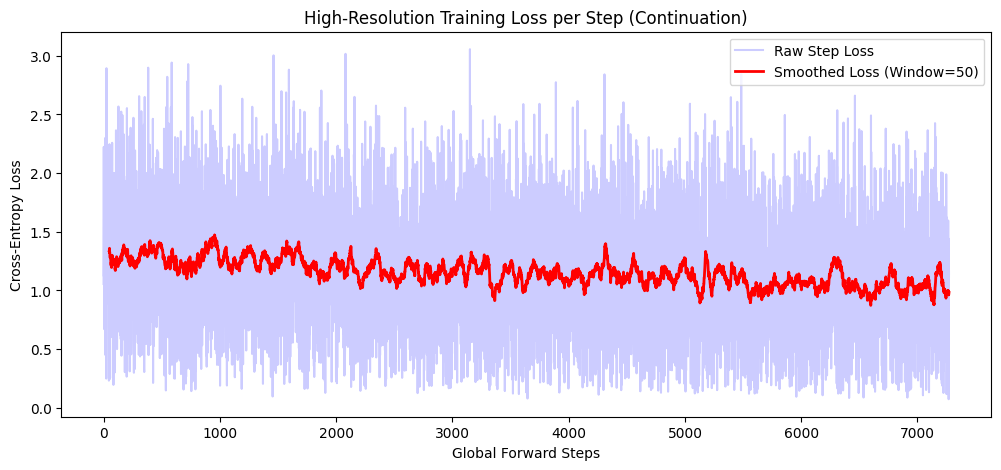


--- ✅ Continuation Training Run Complete (Epochs 4-6) ---


In [ ]:
import os
import random
import time
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import torch
import torch.nn as nn
import torch.backends.cudnn as cudnn
from torch.utils.data import Dataset, DataLoader
from functools import partial
from datasets import load_dataset
from torchvision import transforms
from transformers import AutoImageProcessor, AutoModel, AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig, get_cosine_schedule_with_warmup
from peft import PeftModel

# Optimize CuDNN for static input sizes
cudnn.benchmark = True
device = "cuda" if torch.cuda.is_available() else "cpu"

# ==========================================
# 1. RESUME MODELS & ARCHITECTURE
# ==========================================
print("Loading Architecture and Resuming Weights for T4 GPU...")
PREV_CHECKPOINT_DIR = "/content/drive/MyDrive/msc_medical_vlm_weights_final/checkpoint-epoch-3"

vision_processor = AutoImageProcessor.from_pretrained("microsoft/rad-dino")
vision_encoder = AutoModel.from_pretrained("microsoft/rad-dino").to(device)
vision_encoder.eval()

llm_id = "Qwen/Qwen2.5-3B-Instruct"
tokenizer = AutoTokenizer.from_pretrained(llm_id)
tokenizer.pad_token = tokenizer.eos_token

# T4 OPTIMIZATION
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16
)
base_llm = AutoModelForCausalLM.from_pretrained(llm_id, quantization_config=bnb_config, device_map={"": 0})


print("Loading previously trained LoRA adapters...")
efficient_llm = PeftModel.from_pretrained(
    base_llm,
    os.path.join(PREV_CHECKPOINT_DIR, "qwen_lora_adapters"),
    is_trainable=True
)

class QFormerProjector(nn.Module):
    def __init__(self, num_queries=64, vision_dim=768, llm_dim=3584):
        super().__init__()
        self.query_tokens = nn.Parameter(torch.randn(1, num_queries, vision_dim))
        self.cross_attn = nn.MultiheadAttention(embed_dim=vision_dim, num_heads=8, batch_first=True)
        self.norm1 = nn.LayerNorm(vision_dim)
        self.ffn = nn.Sequential(nn.Linear(vision_dim, vision_dim * 4), nn.GELU(), nn.Linear(vision_dim * 4, vision_dim))
        self.norm2 = nn.LayerNorm(vision_dim)
        self.proj = nn.Linear(vision_dim, llm_dim)
        self.llm_norm = nn.LayerNorm(llm_dim)

    def forward(self, patch_embeddings):
        spatial_patches = patch_embeddings[:, 1:, :]
        batch_size = spatial_patches.shape[0]
        queries = self.query_tokens.expand(batch_size, -1, -1)
        attn_output, _ = self.cross_attn(query=queries, key=spatial_patches, value=spatial_patches)
        x = self.norm1(queries + attn_output)
        x = self.norm2(x + self.ffn(x))
        return self.llm_norm(self.proj(x))

#  Load the previous Q-Former weights
print("Loading previously trained Q-Former Projector...")
projector = QFormerProjector(num_queries=64, vision_dim=768, llm_dim=efficient_llm.config.hidden_size).to(device)
projector.load_state_dict(torch.load(os.path.join(PREV_CHECKPOINT_DIR, "vision_projector.pth"), map_location=device, weights_only=True))

# ==========================================
# 2. DATA LOADER & PIPELINE
# ==========================================
train_transforms = transforms.Compose([
    transforms.RandomAffine(degrees=3, translate=(0.02, 0.02)),
])

class MedicalDataset(Dataset):
    def __init__(self, hf_dataset, transform=None):
        self.dataset = hf_dataset
        self.transform = transform
    def __len__(self): return len(self.dataset)
    def __getitem__(self, idx):
        image = self.dataset[idx]['image']
        if image.mode != 'RGB': image = image.convert('RGB')
        if self.transform: image = self.transform(image)
        return {'image': image, 'report': self.dataset[idx].get('text', "Normal.")}

def get_random_clinical_prompt():
    instructions = [
        "Analyze this chest radiograph and generate a concise clinical report.",
        "Review this CXR and detail findings for the lungs, heart, and pleura.",
        "Provide a structured diagnostic report for this chest X-ray using standard radiology terminology."
    ]
    return (
        "<|im_start|>system\n"
        "You are an expert radiologist. Write ONLY the diagnostic narrative.<|im_end|>\n"
        f"<|im_start|>user\n{random.choice(instructions)}<|im_end|>\n"
        "<|im_start|>assistant\n"
    )

def collate_fn(batch, processor, tokenizer, absolute_max_length=256):
    images = [item['image'] for item in batch]
    reports = [item['report'] for item in batch]
    pixel_inputs = processor(images=images, return_tensors="pt")

    raw_input_ids = []
    raw_labels = []

    for report in reports:
        prompt_ids = tokenizer(get_random_clinical_prompt(), add_special_tokens=False).input_ids
        report_ids = tokenizer(report + "<|im_end|>", add_special_tokens=False).input_ids
        raw_input_ids.append(prompt_ids + report_ids)
        raw_labels.append([-100] * len(prompt_ids) + report_ids)

    current_max_len = max(len(ids) for ids in raw_input_ids)
    target_len = min(current_max_len, absolute_max_length)

    batch_input_ids, batch_labels, batch_attention_mask = [], [], []

    for input_ids, labels in zip(raw_input_ids, raw_labels):
        if len(input_ids) > target_len:
            input_ids = input_ids[:target_len]
            labels = labels[:target_len]
        else:
            pad_len = target_len - len(input_ids)
            input_ids = input_ids + [tokenizer.pad_token_id] * pad_len
            labels = labels + [-100] * pad_len

        batch_input_ids.append(input_ids)
        batch_labels.append(labels)
        batch_attention_mask.append([1 if id != tokenizer.pad_token_id else 0 for id in input_ids])

    return {
        'pixel_values': pixel_inputs.pixel_values,
        'input_ids': torch.tensor(batch_input_ids, dtype=torch.long),
        'labels': torch.tensor(batch_labels, dtype=torch.long),
        'attention_mask': torch.tensor(batch_attention_mask, dtype=torch.long)
    }

print("Preparing 3-Way Dataset Splits...")
full_dataset = load_dataset("Shrey-1329/cxiu_hf_dataset", split="train")
train_test_split = full_dataset.train_test_split(test_size=0.2, seed=42)
val_test_split = train_test_split['test'].train_test_split(test_size=0.5, seed=42)

train_dataset = MedicalDataset(train_test_split['train'], transform=train_transforms)
val_dataset = MedicalDataset(val_test_split['train'], transform=None)
custom_collate = partial(collate_fn, processor=vision_processor, tokenizer=tokenizer)

train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True, collate_fn=custom_collate, num_workers=2, pin_memory=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=2, shuffle=False, collate_fn=custom_collate, num_workers=2, pin_memory=True)

# ==========================================
# 3. CONTINUATION LOOP
# ==========================================
print("Initiating Continuation Training Loop...")
optimizer = torch.optim.AdamW([
    {"params": projector.parameters(), "lr": 1e-4},
    {"params": efficient_llm.parameters(), "lr": 2e-5}
])

scaler = torch.amp.GradScaler('cuda')

START_EPOCH = 3 # We finished epoch 3
ADDITIONAL_EPOCHS = 3
TOTAL_EPOCHS = START_EPOCH + ADDITIONAL_EPOCHS

accumulation_steps = 4
total_update_steps = (len(train_loader) // accumulation_steps) * ADDITIONAL_EPOCHS
#  3% warmup for  continuation phase to ease the model back into training
scheduler = get_cosine_schedule_with_warmup(optimizer, num_warmup_steps=int(total_update_steps * 0.03), num_training_steps=total_update_steps)

epoch_train_losses, epoch_val_losses = [], []
all_step_losses, all_learning_rates = [], []

for epoch in range(START_EPOCH, TOTAL_EPOCHS):
    projector.train()
    efficient_llm.train()
    total_train_loss = 0
    print(f"\n--- Starting Epoch {epoch + 1}/{TOTAL_EPOCHS} ---")

    last_log_time = time.time()

    for step, batch in enumerate(train_loader):
        pixel_values = batch['pixel_values'].to(device, non_blocking=True)
        input_ids = batch['input_ids'].to(device, non_blocking=True)
        text_labels = batch['labels'].to(device, non_blocking=True)
        text_attention_mask = batch['attention_mask'].to(device, non_blocking=True)

        with torch.amp.autocast(device_type="cuda", dtype=torch.float16):
            with torch.no_grad():
                patch_embeddings = vision_encoder(pixel_values).last_hidden_state.to(torch.float16)

            visual_prompts = projector(patch_embeddings)
            text_embeddings = efficient_llm.get_input_embeddings()(input_ids)
            combined_embeddings = torch.cat([visual_prompts, text_embeddings], dim=1)

            batch_size, num_visual_tokens = input_ids.shape[0], visual_prompts.shape[1]
            visual_labels = torch.full((batch_size, num_visual_tokens), -100, dtype=torch.long, device=device)
            aligned_labels = torch.cat([visual_labels, text_labels], dim=1)
            visual_attn_mask = torch.ones((batch_size, num_visual_tokens), dtype=torch.long, device=device)
            aligned_attention_mask = torch.cat([visual_attn_mask, text_attention_mask], dim=1)

            outputs = efficient_llm(inputs_embeds=combined_embeddings, attention_mask=aligned_attention_mask, labels=aligned_labels)

            raw_loss = outputs.loss.to(torch.float32)
            loss = raw_loss / accumulation_steps

        scaler.scale(loss).backward()

        if (step + 1) % accumulation_steps == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(list(projector.parameters()) + list(efficient_llm.parameters()), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            optimizer.zero_grad(set_to_none=True)

            all_learning_rates.append(scheduler.get_last_lr()[0])

        total_train_loss += raw_loss.item()
        all_step_losses.append(raw_loss.item())

        if step % 50 == 0:
            current_time = time.time()
            elapsed = current_time - last_log_time
            steps_passed = 50 if step > 0 else 1
            time_per_step = elapsed / steps_passed

            print(f"Step {step:04d}/{len(train_loader)} | "
                  f"Loss: {raw_loss.item():.4f} | "
                  f"LR: {scheduler.get_last_lr()[0]:.2e} | "
                  f"Time/Step: {time_per_step:.2f}s")

            last_log_time = time.time()

    avg_train_loss = total_train_loss / len(train_loader)
    epoch_train_losses.append(avg_train_loss)

    # --- VALIDATION PHASE ---
    print(f"\nEvaluating Validation Set for Epoch {epoch + 1}...")
    projector.eval()
    efficient_llm.eval()
    total_val_loss = 0

    with torch.no_grad():
        for val_step, val_batch in enumerate(val_loader):
            pixel_values = val_batch['pixel_values'].to(device, non_blocking=True)
            input_ids = val_batch['input_ids'].to(device, non_blocking=True)
            text_labels = val_batch['labels'].to(device, non_blocking=True)
            text_attention_mask = val_batch['attention_mask'].to(device, non_blocking=True)

            with torch.amp.autocast(device_type="cuda", dtype=torch.float16):
                patch_embeddings = vision_encoder(pixel_values).last_hidden_state.to(torch.float16)
                visual_prompts = projector(patch_embeddings)
                text_embeddings = efficient_llm.get_input_embeddings()(input_ids)

                combined_embeddings = torch.cat([visual_prompts, text_embeddings], dim=1)
                batch_size, num_visual_tokens = input_ids.shape[0], visual_prompts.shape[1]

                visual_labels = torch.full((batch_size, num_visual_tokens), -100, dtype=torch.long, device=device)
                aligned_labels = torch.cat([visual_labels, text_labels], dim=1)
                visual_attn_mask = torch.ones((batch_size, num_visual_tokens), dtype=torch.long, device=device)
                aligned_attention_mask = torch.cat([visual_attn_mask, text_attention_mask], dim=1)

                val_outputs = efficient_llm(inputs_embeds=combined_embeddings, attention_mask=aligned_attention_mask, labels=aligned_labels)
                total_val_loss += val_outputs.loss.item()

    avg_val_loss = total_val_loss / len(val_loader)
    epoch_val_losses.append(avg_val_loss)
    print(f"Epoch {epoch + 1} Results -> Train Loss: {avg_train_loss:.4f} | Validation Loss: {avg_val_loss:.4f}")

    torch.cuda.empty_cache()

    # ==========================================
    # 4. SAVING & PLOTTING (PER EPOCH)
    # ==========================================

    SAVE_DIR = f"/content/drive/MyDrive/msc_medical_vlm_weights_final/checkpoint-epoch-{epoch + 1}"
    os.makedirs(SAVE_DIR, exist_ok=True)

    efficient_llm.save_pretrained(os.path.join(SAVE_DIR, "qwen_lora_adapters"))
    torch.save(projector.state_dict(), os.path.join(SAVE_DIR, "vision_projector.pth"))

    plt.figure(figsize=(10, 6))
    plt.plot(range(START_EPOCH + 1, epoch + 2), epoch_train_losses, label='Training Loss', marker='o', color='blue')
    plt.plot(range(START_EPOCH + 1, epoch + 2), epoch_val_losses, label='Validation Loss', marker='s', color='orange')
    plt.title(f'VLM Model Continuation Convergence (Epoch {epoch + 1})')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
    plt.legend()
    plt.savefig(os.path.join(SAVE_DIR, "continuation_learning_curve.png"))
    plt.close()

# ==========================================
# 5. FINAL HIGH-RESOLUTION GRAPHS
# ==========================================
print("\nGenerating Final Training Analysis Graphs...")
FINAL_DIR = "/content/drive/MyDrive/msc_medical_vlm_weights_final/"

plt.figure(figsize=(10, 4))
plt.plot(all_learning_rates, color='green')
plt.title('Cosine Learning Rate Schedule with Warmup (Continuation)')
plt.xlabel('Optimization Steps')
plt.ylabel('Learning Rate')
plt.grid(True, alpha=0.3)
plt.savefig(os.path.join(FINAL_DIR, "continuation_lr_schedule.png"))
plt.close()

smoothed_loss = pd.Series(all_step_losses).rolling(window=50).mean()
plt.figure(figsize=(12, 5))
plt.plot(all_step_losses, alpha=0.2, color='blue', label='Raw Step Loss')
plt.plot(smoothed_loss, color='red', linewidth=2, label='Smoothed Loss (Window=50)')
plt.title('High-Resolution Training Loss per Step (Continuation)')
plt.xlabel('Global Forward Steps')
plt.ylabel('Cross-Entropy Loss')
plt.legend()
plt.savefig(os.path.join(FINAL_DIR, "continuation_step_loss.png"))
plt.show()

print("\n--- ✅ Continuation Training Run Complete (Epochs 4-6) ---")

# Evaluation-

In [ ]:
!pip install rouge_score nltk bert-score

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 3.6 MB/s eta 0:00:00
  Created wheel for rouge_score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=a163a937f521d3dbb66c84c02902a1a88c5f6cf35a5d9c6662dfccc2790e0625
  Stored in directory: /root/.cache/pip/wheels/85/9d/af/01feefbe7d55ef5468796f0c68225b6788e85d9d0a281e7a70
Successfully built rouge_score


# Setup and Model Loading

*   From dataset split cell ,direct run this cell to evaluate




In [ ]:
!pip install -U bitsandbytes>=0.46.1

# the session needs to be restart and then run the following cell

In [ ]:
import os
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from datasets import load_dataset
from transformers import AutoImageProcessor, AutoModel, AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from peft import PeftModel
from tqdm import tqdm
import nltk
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rouge_score import rouge_scorer
from bert_score import score as bert_score

# Download required NLTK dictionaries for BLEU scoring
nltk.download('punkt')
nltk.download('punkt_tab')

device = "cuda" if torch.cuda.is_available() else "cpu"
CHECKPOINT_DIR = "/content/drive/MyDrive/msc_medical_vlm_weights_final/checkpoint-epoch-6"

print("1. Loading Holdout Test Set...")
full_dataset = load_dataset("Shrey-1329/cxiu_hf_dataset", split="train")
train_test_split = full_dataset.train_test_split(test_size=0.2, seed=42)
test_val_pool = train_test_split['test']
val_test_split = test_val_pool.train_test_split(test_size=0.5, seed=42)
test_split = val_test_split['test'] # The untouched 10%

print("2. Loading Base Models...")
vision_processor = AutoImageProcessor.from_pretrained("microsoft/rad-dino")
vision_encoder = AutoModel.from_pretrained("microsoft/rad-dino").to(device)
vision_encoder.eval()

llm_id = "Qwen/Qwen2.5-3B-Instruct"
tokenizer = AutoTokenizer.from_pretrained(llm_id)
tokenizer.pad_token = tokenizer.eos_token


bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16
)
base_llm = AutoModelForCausalLM.from_pretrained(llm_id, quantization_config=bnb_config, device_map={"": 0})

print("3. Loading Trained Weights (Epoch 6)...")
efficient_llm = PeftModel.from_pretrained(base_llm, os.path.join(CHECKPOINT_DIR, "qwen_lora_adapters"))
efficient_llm.eval()

class QFormerProjector(nn.Module):
    def __init__(self, num_queries=64, vision_dim=768, llm_dim=3584):
        super().__init__()
        self.query_tokens = nn.Parameter(torch.randn(1, num_queries, vision_dim))
        self.cross_attn = nn.MultiheadAttention(embed_dim=vision_dim, num_heads=8, batch_first=True)
        self.norm1 = nn.LayerNorm(vision_dim)
        self.ffn = nn.Sequential(nn.Linear(vision_dim, vision_dim * 4), nn.GELU(), nn.Linear(vision_dim * 4, vision_dim))
        self.norm2 = nn.LayerNorm(vision_dim)
        self.proj = nn.Linear(vision_dim, llm_dim)
        self.llm_norm = nn.LayerNorm(llm_dim)

    def forward(self, patch_embeddings, return_attention=False):
        spatial_patches = patch_embeddings[:, 1:, :]
        batch_size = spatial_patches.shape[0]
        queries = self.query_tokens.expand(batch_size, -1, -1)


        attn_output, cross_attn_weights = self.cross_attn(query=queries, key=spatial_patches, value=spatial_patches, need_weights=return_attention)

        x = self.norm1(queries + attn_output)
        x = self.norm2(x + self.ffn(x))
        final_tokens = self.llm_norm(self.proj(x))

        if return_attention:
            return final_tokens, cross_attn_weights
        return final_tokens

projector = QFormerProjector(num_queries=64, vision_dim=768, llm_dim=efficient_llm.config.hidden_size).to(device)
projector.load_state_dict(torch.load(os.path.join(CHECKPOINT_DIR, "vision_projector.pth"), map_location=device, weights_only=True))
projector.eval()

print("Environment Ready!")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


1. Loading Holdout Test Set...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


2. Loading Base Models...


Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

...

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

3. Loading Trained Weights (Epoch 6)...
Environment Ready!


# NLG Evaluation-BLEU , ROGUE, BertScore

*   running on whole test set
  



In [ ]:
import pandas as pd
from tqdm import tqdm


print("1. Loading Holdout Test Set...")
full_dataset = load_dataset("Shrey-1329/cxiu_hf_dataset", split="train")
train_test_split = full_dataset.train_test_split(test_size=0.2, seed=42)
test_val_pool = train_test_split['test']
val_test_split = test_val_pool.train_test_split(test_size=0.5, seed=42)
test_split = val_test_split['test'] # The untouched 10%


print("Commencing Quantitative Evaluation on Test Set...")

eval_prompt = (
    "<|im_start|>system\n"
    "You are an expert radiologist. Write ONLY the diagnostic clinical narrative.<|im_end|>\n"
    "<|im_start|>user\nAnalyze this chest radiograph and generate a concise clinical report.<|im_end|>\n"
    "<|im_start|>assistant\n"
)
prompt_ids = tokenizer(eval_prompt, return_tensors="pt").input_ids.to(device)

all_generated_reports = []
all_reference_reports = []

# Using the FULL test split for thesis results

with torch.no_grad():
    for item in tqdm(test_split, desc="Generating Reports"):
        image = item['image'].convert('RGB')
        pixel_values = vision_processor(images=image, return_tensors="pt").pixel_values.to(device)

        # THE FIX: Wrap the ENTIRE forward pass in the correct float16 autocast
        with torch.amp.autocast(device_type="cuda", dtype=torch.float16):

            # THE FIX: Explicitly cast DINO's output to float16 to match your training code
            patch_embeddings = vision_encoder(pixel_values).last_hidden_state.to(torch.float16)
            visual_prompts = projector(patch_embeddings)

            prompt_embeds = efficient_llm.get_input_embeddings()(prompt_ids)

            # Combine text and vision tokens
            inputs_embeds = torch.cat([visual_prompts, prompt_embeds], dim=1)
            attention_mask = torch.ones(inputs_embeds.shape[:2], dtype=torch.long, device=device)

            # Generate the report
            outputs = efficient_llm.generate(
                inputs_embeds=inputs_embeds,
                attention_mask=attention_mask,
                max_new_tokens=100,
                do_sample=False, # STRICT GREEDY DECODING
                repetition_penalty=1.1,
                eos_token_id=tokenizer.eos_token_id
            )

        gen_text = tokenizer.decode(outputs[0], skip_special_tokens=True).strip()
        ref_text = item.get('text', "Normal.").strip()
        all_generated_reports.append(gen_text)
        all_reference_reports.append(ref_text)

# ==========================================
# 💾 SAVE POINT: SECURE THE DATA TO DRIVE
# ==========================================
print("\nGeneration complete! Saving reports to Google Drive...")
df = pd.DataFrame({
    'generated_report': all_generated_reports,
    'reference_report': all_reference_reports
})

save_path = "/content/drive/MyDrive/msc_final_evaluation_reports.csv"
df.to_csv(save_path, index=False)
print(f"✅ Successfully saved {len(df)} reports to: {save_path}")
# ==========================================


print("\nCalculating Final Metrics...")
scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
chencherry = SmoothingFunction()
rouge1_scores, rouge2_scores, rougeL_scores, bleu_scores = [], [], [], []

for gen, ref in zip(all_generated_reports, all_reference_reports):
    scores = scorer.score(ref, gen)
    rouge1_scores.append(scores['rouge1'].fmeasure)
    rouge2_scores.append(scores['rouge2'].fmeasure)
    rougeL_scores.append(scores['rougeL'].fmeasure)
    ref_tokens = nltk.word_tokenize(ref.lower())
    gen_tokens = nltk.word_tokenize(gen.lower())
    bleu_scores.append(sentence_bleu([ref_tokens], gen_tokens, smoothing_function=chencherry.method1))

P, R, F1 = bert_score(all_generated_reports, all_reference_reports, lang="en", verbose=False)

print("\n" + "="*40)
print(f"🏆 OFFICIAL EVALUATION METRICS (n={len(test_split)}) 🏆")
print("="*40)
print(f"Average BLEU Score:   {sum(bleu_scores)/len(bleu_scores):.4f}")
print(f"Average ROUGE-1 F1:   {sum(rouge1_scores)/len(rouge1_scores):.4f}")
print(f"Average ROUGE-2 F1:   {sum(rouge2_scores)/len(rouge2_scores):.4f}")
print(f"Average ROUGE-L F1:   {sum(rougeL_scores)/len(rougeL_scores):.4f}")
print(f"Average BERTScore F1: {F1.mean().item():.4f}")
print("="*40)

1. Loading Holdout Test Set...
Commencing Quantitative Evaluation on Test Set...


Generating Reports: 100%|██████████| 606/606 [1:05:36<00:00,  6.50s/it]



Generation complete! Saving reports to Google Drive...
✅ Successfully saved 606 reports to: /content/drive/MyDrive/msc_final_evaluation_reports.csv

Calculating Final Metrics...


config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



🏆 OFFICIAL EVALUATION METRICS (n=606) 🏆
Average BLEU Score:   0.0830
Average ROUGE-1 F1:   0.4425
Average ROUGE-2 F1:   0.1681
Average ROUGE-L F1:   0.3141
Average BERTScore F1: 0.8757


#  Visual Grounding - "Heatmap Generator" and report generation

/usr/local/lib/python3.12/dist-packages/transformers/generation/utils.py:1113: UserWarning: Passing `repetition_penalty` with `inputs_embeds` and without `input_ids` to `generate` will apply the penalty only to newly generated tokens, not to the prompt.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


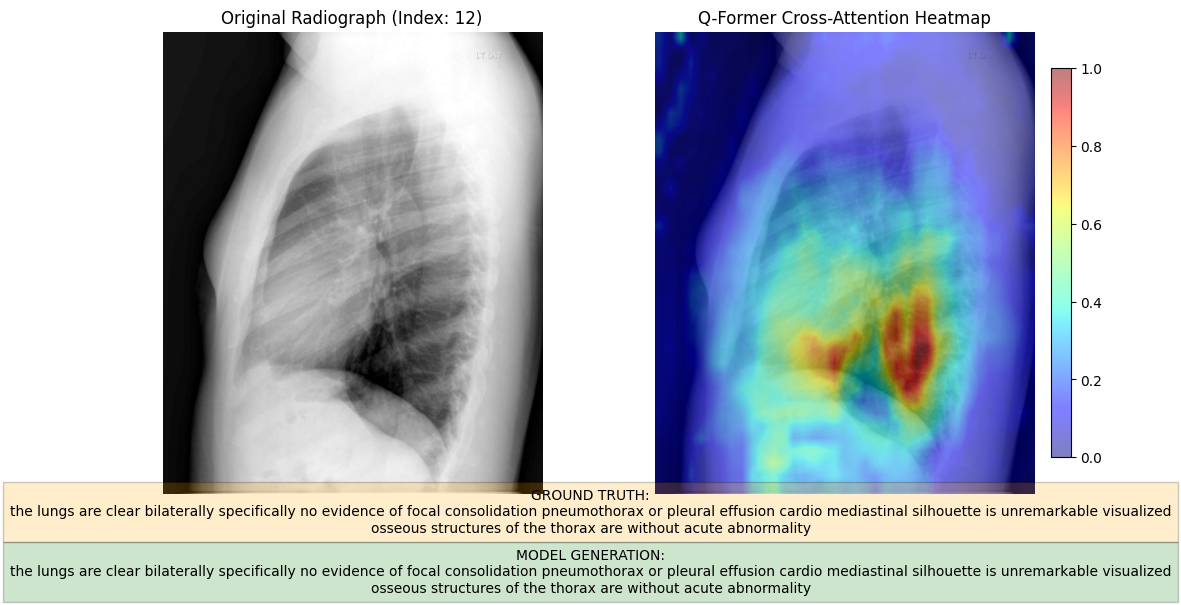

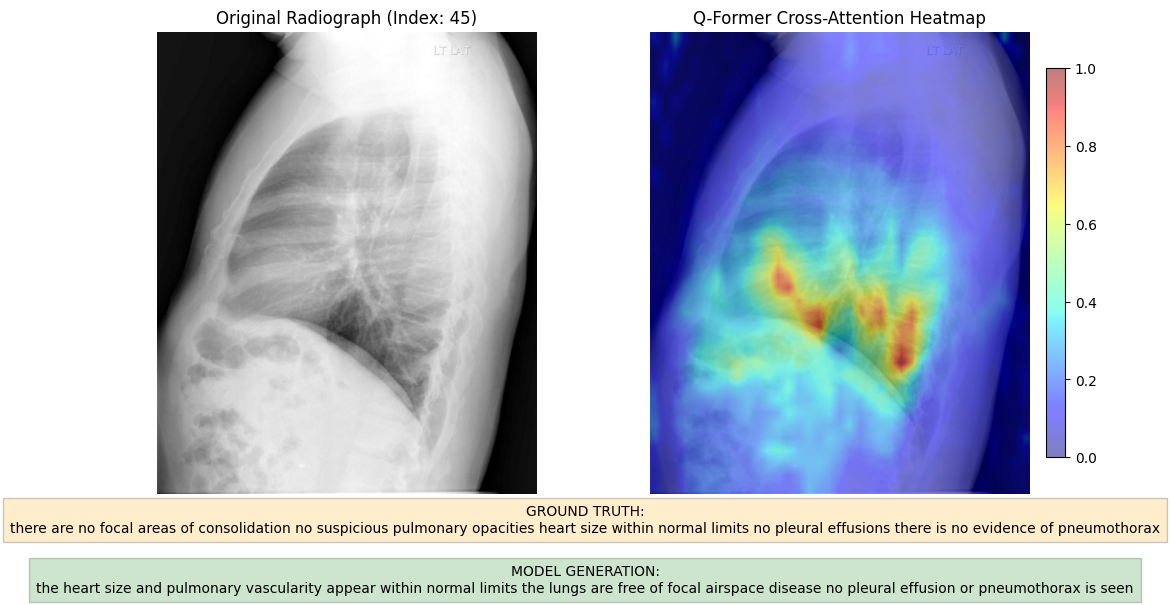

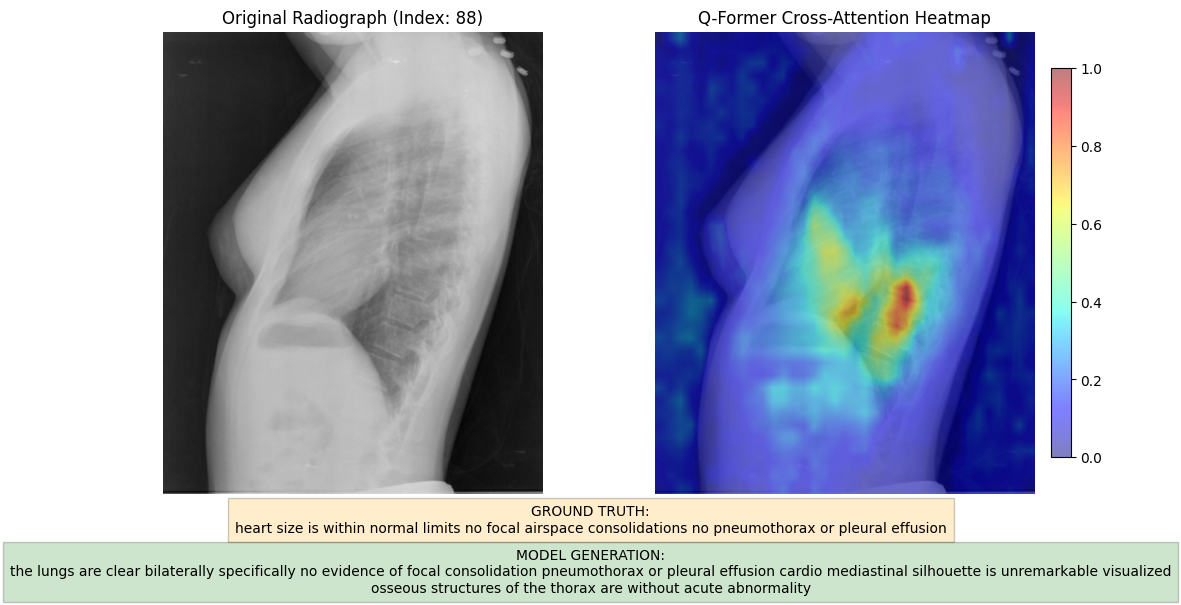

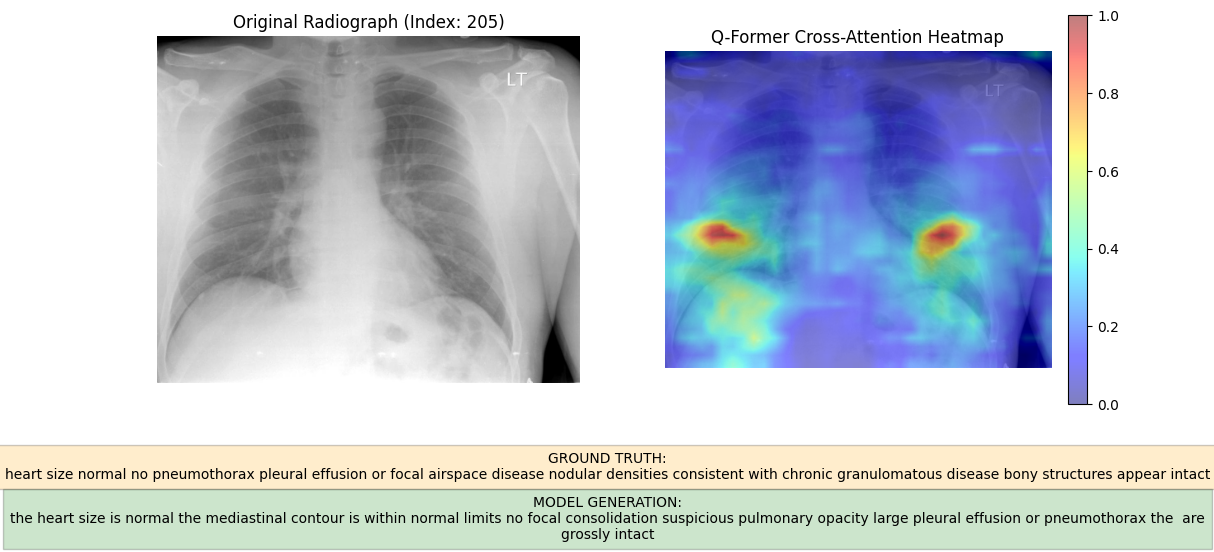

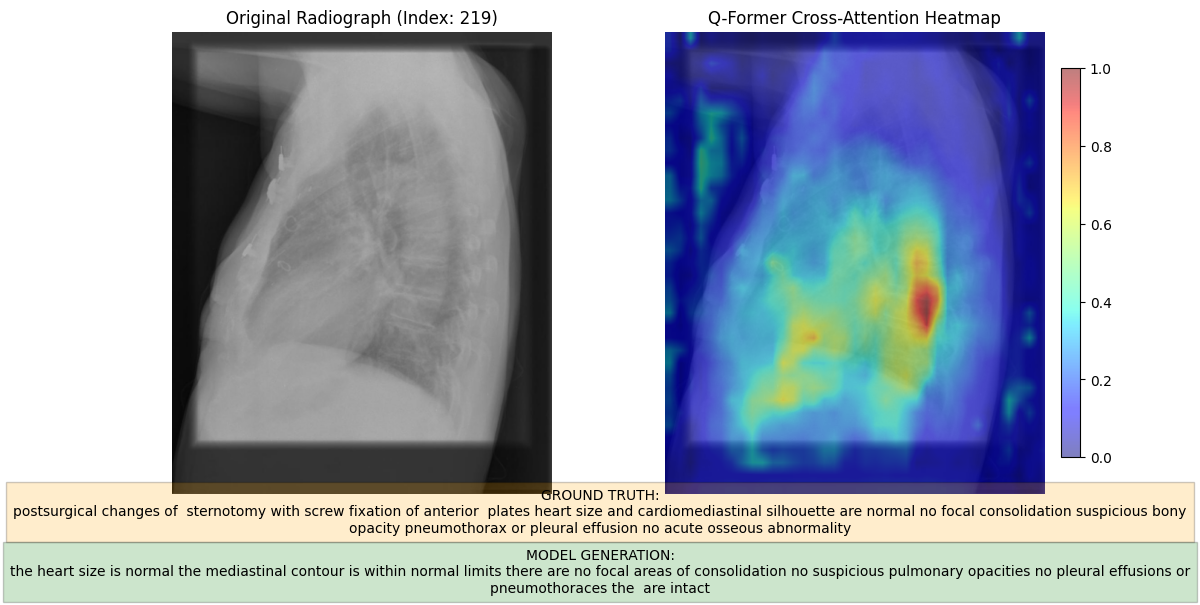

In [ ]:
def generate_grounding_heatmap(image_index):
    item = test_split[image_index]
    image = item['image'].convert('RGB')
    original_report = item.get('text', 'Normal.')

    pixel_values = vision_processor(images=image, return_tensors="pt").pixel_values.to(device)

    with torch.no_grad():

        with torch.amp.autocast(device_type="cuda", dtype=torch.float16):


            vision_outputs = vision_encoder(pixel_values)
            patch_embeddings = vision_outputs.last_hidden_state.to(torch.float16)

            # Trigger attention trapdoor
            visual_prompts, attn_weights = projector(patch_embeddings, return_attention=True)

            eval_prompt = (
                "<|im_start|>system\n"
                "You are an expert radiologist. Write ONLY the diagnostic clinical narrative.<|im_end|>\n"
                "<|im_start|>user\nAnalyze this chest radiograph and generate a concise clinical report.<|im_end|>\n"
                "<|im_start|>assistant\n"
            )
            prompt_ids = tokenizer(eval_prompt, return_tensors="pt").input_ids.to(device)
            prompt_embeds = efficient_llm.get_input_embeddings()(prompt_ids)
            inputs_embeds = torch.cat([visual_prompts, prompt_embeds], dim=1)
            attention_mask = torch.ones(inputs_embeds.shape[:2], dtype=torch.long, device=device)

            # Generate
            outputs = efficient_llm.generate(
                inputs_embeds=inputs_embeds,
                attention_mask=attention_mask,
                max_new_tokens=100,
                do_sample=False,
                repetition_penalty=1.1,
                eos_token_id=tokenizer.eos_token_id
            )

    generated_text = tokenizer.decode(outputs[0], skip_special_tokens=True).strip()

    # ==========================================
    #  HEATMAP MATH & PLOTTING
    # ==========================================
    avg_attention = attn_weights.squeeze(0).mean(dim=0)
    grid_size = int(math.sqrt(avg_attention.shape[0]))
    attention_grid = avg_attention.view(1, 1, grid_size, grid_size)

    original_w, original_h = image.size
    upscaled_attention = F.interpolate(attention_grid, size=(original_h, original_w), mode='bilinear', align_corners=False)
    heatmap = upscaled_attention.squeeze().cpu().numpy()
    heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min())

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    axes[0].imshow(image, cmap='gray')
    axes[0].set_title(f"Original Radiograph (Index: {image_index})")
    axes[0].axis('off')

    axes[1].imshow(image, cmap='gray')
    im = axes[1].imshow(heatmap, cmap='jet', alpha=0.5)
    axes[1].set_title("Q-Former Cross-Attention Heatmap")
    axes[1].axis('off')
    fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

    plt.figtext(0.5, 0.05, f"GROUND TRUTH:\n{original_report}", wrap=True, horizontalalignment='center', fontsize=10, bbox={"facecolor":"orange", "alpha":0.2, "pad":5})
    plt.figtext(0.5, -0.05, f"MODEL GENERATION:\n{generated_text}", wrap=True, horizontalalignment='center', fontsize=10, bbox={"facecolor":"green", "alpha":0.2, "pad":5})
    plt.show()


test_indices = [12, 45, 88,205,219]
for idx in test_indices:
    generate_grounding_heatmap(idx)